sales_data.csv not found, creating dummy data.
First 5 rows:
         date       sales
0  2022-01-01  224.000000
1  2022-01-02  196.991671
2  2022-01-03  120.933467
3  2022-01-04  142.776010
4  2022-01-05  396.470917


/tmp/ipykernel_1606/1295339108.py:42: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['sales'] = data['sales'].fillna(method='ffill')


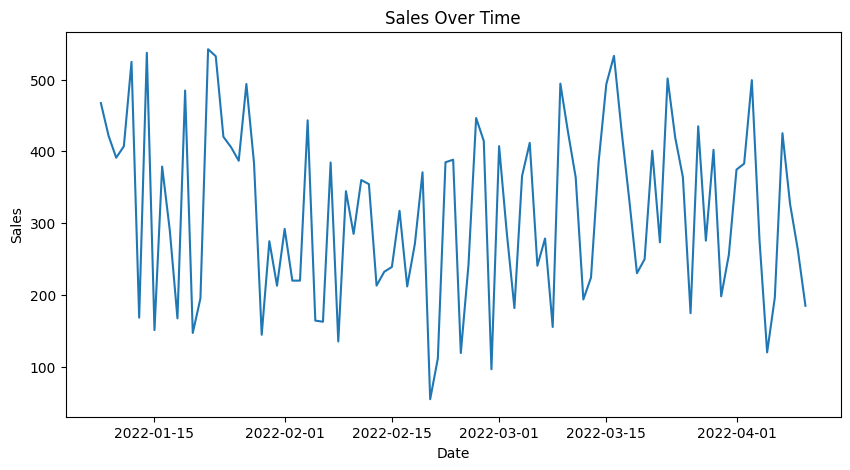

Linear Regression MAE: 99.52869178887309
Linear Regression RMSE: 113.53314993620202
------------------------
Random Forest MAE: 97.3496338320655
Random Forest RMSE: 112.58898547455978
------------------------


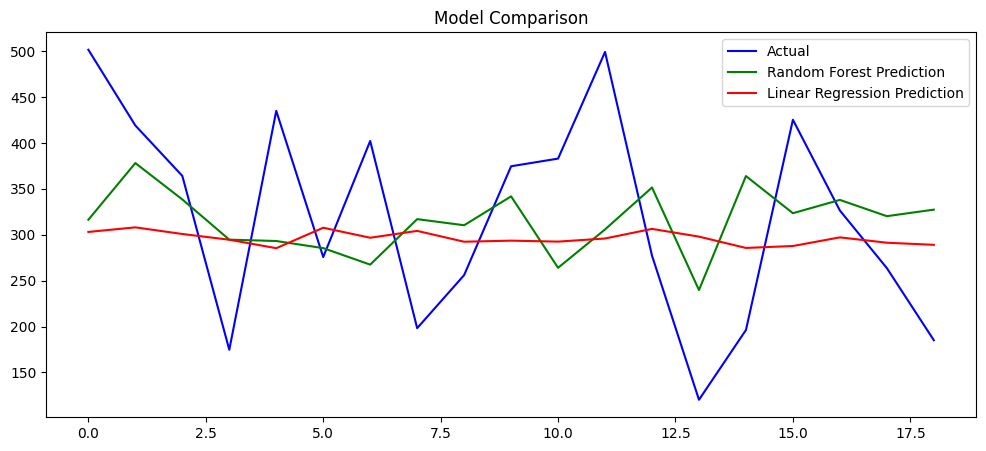

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/


Future Predictions:
            day  month  year  day_of_week  predicted_sales
2022-04-11   11      4  2022            0       369.160817
2022-04-12   12      4  2022            1       316.687110
2022-04-13   13      4  2022            2       311.669506
2022-04-14   14      4  2022            3       272.501210
2022-04-15   15      4  2022            4       347.698620
2022-04-16   16      4  2022            5       283.850972
2022-04-17   17      4  2022            6       232.249382
2022-04-18   18      4  2022            0       343.157323
2022-04-19   19      4  2022            1       312.957065
2022-04-20   20      4  2022            2       310.432898


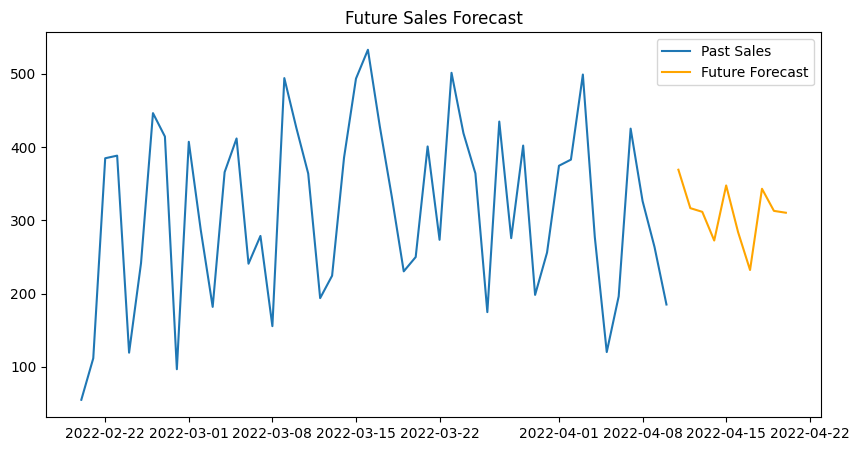

In [ ]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os # Import os module to check for file existence

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==============================
# 2. Load Dataset
# ==============================
# Replace with your file path
# Make sure 'sales_data.csv' is uploaded to your Colab environment or provide the correct path.

# Check if sales_data.csv exists, if not, create a dummy one for demonstration
if not os.path.exists('sales_data.csv'):
    print("sales_data.csv not found, creating dummy data.")
    # Create a dummy dataframe
    dates = pd.date_range(start='2022-01-01', periods=100, freq='D')
    sales = np.random.randint(100, 500, size=100) + np.sin(np.arange(100)/10) * 50
    dummy_data = pd.DataFrame({'date': dates, 'sales': sales})
    dummy_data.to_csv('sales_data.csv', index=False)

data = pd.read_csv("sales_data.csv")

print("First 5 rows:")
print(data.head())

# ==============================
# 3. Data Preprocessing
# ==============================
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values('date')
data.set_index('date', inplace=True)

# Handle missing values
data['sales'] = data['sales'].fillna(method='ffill')

# ==============================
# 4. Feature Engineering
# ==============================
data['day'] = data.index.day
data['month'] = data.index.month
data['year'] = data.index.year
data['day_of_week'] = data.index.dayofweek

# Lag features (important for forecasting)
data['lag_1'] = data['sales'].shift(1)
data['lag_7'] = data['sales'].shift(7)

data = data.dropna()

# ==============================
# 5. Visualization
# ==============================
plt.figure(figsize=(10,5))
plt.plot(data['sales'])
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# ==============================
# 6. Split Data
# ==============================
X = data[['day','month','year','day_of_week','lag_1','lag_7']]
y = data['sales']

# Time-based split (no shuffle)
split = int(len(data) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ==============================
# 7. Train Models
# ==============================

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Random Forest (better)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# ==============================
# 8. Predictions
# ==============================
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# ==============================
# 9. Evaluation
# ==============================
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name} MAE:", mae)
    print(f"{model_name} RMSE:", rmse)
    print("------------------------")

evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")

# ==============================
# 10. Plot Results
# ==============================
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual", color='blue')
plt.plot(rf_pred, label="Random Forest Prediction", color='green')
plt.plot(lr_pred, label="Linear Regression Prediction", color='red')
plt.legend()
plt.title("Model Comparison")
plt.show()

# ==============================
# 11. Future Forecast (Next 10 Days)
# ==============================
future_dates = pd.date_range(start=data.index[-1], periods=11, freq='D')[1:]

future_df = pd.DataFrame(index=future_dates)
future_df['day'] = future_df.index.day
future_df['month'] = future_df.index.month
future_df['year'] = future_df.index.year
future_df['day_of_week'] = future_df.index.dayofweek

# Use last known values for lag features
last_sales = data['sales'].iloc[-7:].values

future_sales = []

for i in range(len(future_df)):
    lag_1 = last_sales[-1]
    lag_7 = last_sales[0]

    features = [[
        future_df.iloc[i]['day'],
        future_df.iloc[i]['month'],
        future_df.iloc[i]['year'],
        future_df.iloc[i]['day_of_week'],
        lag_1,
        lag_7
    ]]

    pred = rf_model.predict(features)[0]
    future_sales.append(pred)

    # update lag values
    last_sales = np.append(last_sales[1:], pred)

future_df['predicted_sales'] = future_sales

print("\nFuture Predictions:")
print(future_df)

# ==============================
# 12. Plot Future Forecast
# ==============================
plt.figure(figsize=(10,5))
plt.plot(data.index[-50:], data['sales'][-50:], label="Past Sales")
plt.plot(future_df.index, future_df['predicted_sales'], label="Future Forecast", color='orange')
plt.legend()
plt.title("Future Sales Forecast")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("sales_data.csv")
print(data.head())

         date       sales
0  2022-01-01  224.000000
1  2022-01-02  196.991671
2  2022-01-03  120.933467
3  2022-01-04  142.776010
4  2022-01-05  396.470917


In [ ]:
data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)

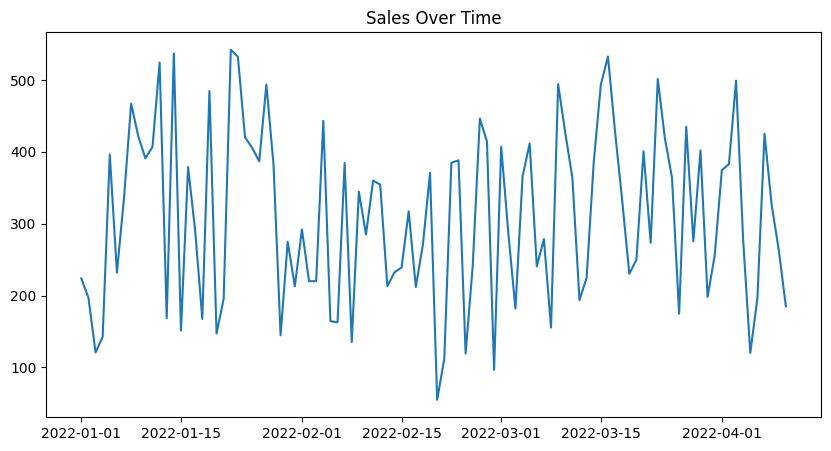

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(data['sales'])
plt.title("Sales Over Time")
plt.show()

In [ ]:
data['day'] = data.index.day
data['month'] = data.index.month
data['year'] = data.index.year

In [ ]:
from sklearn.model_selection import train_test_split

X = data[['day','month','year']]
y = data['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
predictions = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
print("MAE:", mae)

MAE: 97.03895884545966


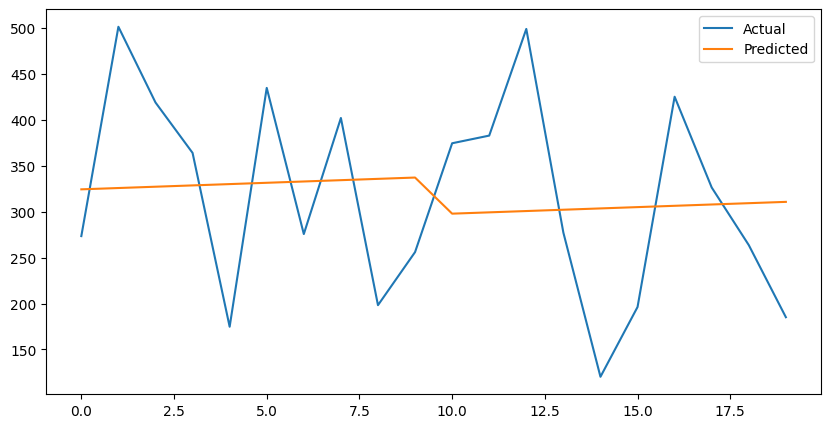

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.show()

In [ ]:
future_dates = pd.date_range(start='2024-01-01', periods=10)

future_df = pd.DataFrame({
    'day': future_dates.day,
    'month': future_dates.month,
    'year': future_dates.year
})

future_sales = model.predict(future_df)
print(future_sales)

[287.53815991 288.96468638 290.39121285 291.81773932 293.2442658
 294.67079227 296.09731874 297.52384521 298.95037168 300.37689815]
